# Method 2 — Matched Filter + Thresholding

**Pipeline**
```
CT image
→ matched filter bank (line-shaped Gaussian kernels at N orientations)
→ max response over all orientations
→ percentile / Otsu threshold
→ morphology cleanup
→ binary mask  (0 = background, 255 = crack)
```

The idea: a line-like object has a specific cross-sectional profile (bright ridge against a darker background).  
We scan the image with elongated Gaussian kernels at many orientations and keep pixels that produce a strong response in *any* direction — those are crack pixels.

*"Matched-filter-based unsupervised segmentation."*  
Reference: Oliveira et al., "Unsupervised Retinal Vessel Segmentation Using Combined Filters," PLOS ONE, 2016.

## Configuration

In [ ]:
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
SAMPLES_DIR = Path("../samples")
OUTPUT_DIR  = Path("output/method2_matched_filter")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Filter bank ────────────────────────────────────────────────────────────
N_ORIENTATIONS = 12        # number of angles spanning [0°, 180°)
SIGMA_X        = 1.5       # cross-sectional width of the Gaussian (crack width)
SIGMA_Y        = 6.0       # along-line length of the Gaussian (crack length)
KERNEL_SIZE    = 25        # filter kernel size in pixels (must be odd)

# ── Thresholding ───────────────────────────────────────────────────────────
THRESHOLD_METHOD = "percentile"   # "percentile" | "otsu"
PERCENTILE       = 97.0           # used when THRESHOLD_METHOD == "percentile"

# ── Post-processing ────────────────────────────────────────────────────────
MIN_COMPONENT_SIZE = 100   # remove connected components smaller than this (px)

print("Configuration loaded.")

Configuration loaded.


## Imports

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, rotate
from skimage import io, img_as_float
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, binary_closing, disk

print("Imports OK.")

Imports OK.


## Pipeline functions

In [14]:
def load_grayscale(path: Path) -> np.ndarray:
    """Load image as float64 grayscale in [0, 1]."""
    img = io.imread(str(path))
    if img.ndim == 3:
        img = rgb2gray(img)
    return img_as_float(img)


def build_base_kernel(sigma_x: float, sigma_y: float, size: int) -> np.ndarray:
    """Build a horizontal line-shaped Gaussian matched filter kernel.

    The kernel models the cross-sectional profile of a bright crack:
      - narrow Gaussian along x (perpendicular to the crack)
      - broad Gaussian along y (along the crack length)
    The mean is subtracted so the filter responds to ridges, not to
    global brightness shifts.
    """
    half = size // 2
    xs = np.linspace(-half, half, size)
    ys = np.linspace(-half, half, size)
    X, Y = np.meshgrid(xs, ys)
    kernel = np.exp(-(X**2 / (2 * sigma_x**2) + Y**2 / (2 * sigma_y**2)))
    kernel -= kernel.mean()   # zero-mean → DC-free ridge detector
    return kernel


def build_filter_bank(n: int, sigma_x: float, sigma_y: float, size: int):
    """Return a list of (angle_deg, kernel) for n evenly-spaced orientations."""
    base = build_base_kernel(sigma_x, sigma_y, size)
    angles = np.linspace(0, 180, n, endpoint=False)
    return [(angle, rotate(base, angle, reshape=False)) for angle in angles]


def apply_filter_bank(img: np.ndarray, filter_bank) -> np.ndarray:
    """Convolve the image with every kernel and take the pixel-wise maximum.

    Returns the max-response map — high values indicate crack-like ridges
    at *any* orientation.
    """
    responses = np.stack(
        [convolve(img, kernel, mode="reflect") for _, kernel in filter_bank],
        axis=0,
    )
    return responses.max(axis=0)


def threshold_response(response: np.ndarray) -> np.ndarray:
    """Convert the max-response map to a binary mask."""
    if THRESHOLD_METHOD == "percentile":
        # Use non-negative part of the response (negative = trough, not ridge)
        pos = response[response > 0]
        if pos.size == 0:
            return np.zeros_like(response, dtype=bool)
        thresh = np.percentile(pos, PERCENTILE)
        return response > thresh
    elif THRESHOLD_METHOD == "otsu":
        return response > threshold_otsu(response)
    else:
        raise ValueError(f"Unknown threshold method: {THRESHOLD_METHOD!r}")


def postprocess(binary: np.ndarray) -> np.ndarray:
    """Remove small noise blobs and lightly close gaps."""
    cleaned = remove_small_objects(binary, min_size=MIN_COMPONENT_SIZE)
    return binary_closing(cleaned, footprint=disk(1))


def save_mask(mask: np.ndarray, out_path: Path) -> None:
    """Save boolean mask as 8-bit PNG (0 = background, 255 = crack)."""
    out_path.parent.mkdir(parents=True, exist_ok=True)
    io.imsave(str(out_path), (mask.astype(np.uint8)) * 255, check_contrast=False)


print("Functions defined.")

Functions defined.


## Visualise the filter bank

Inspect the 12 oriented kernels before running on real images.

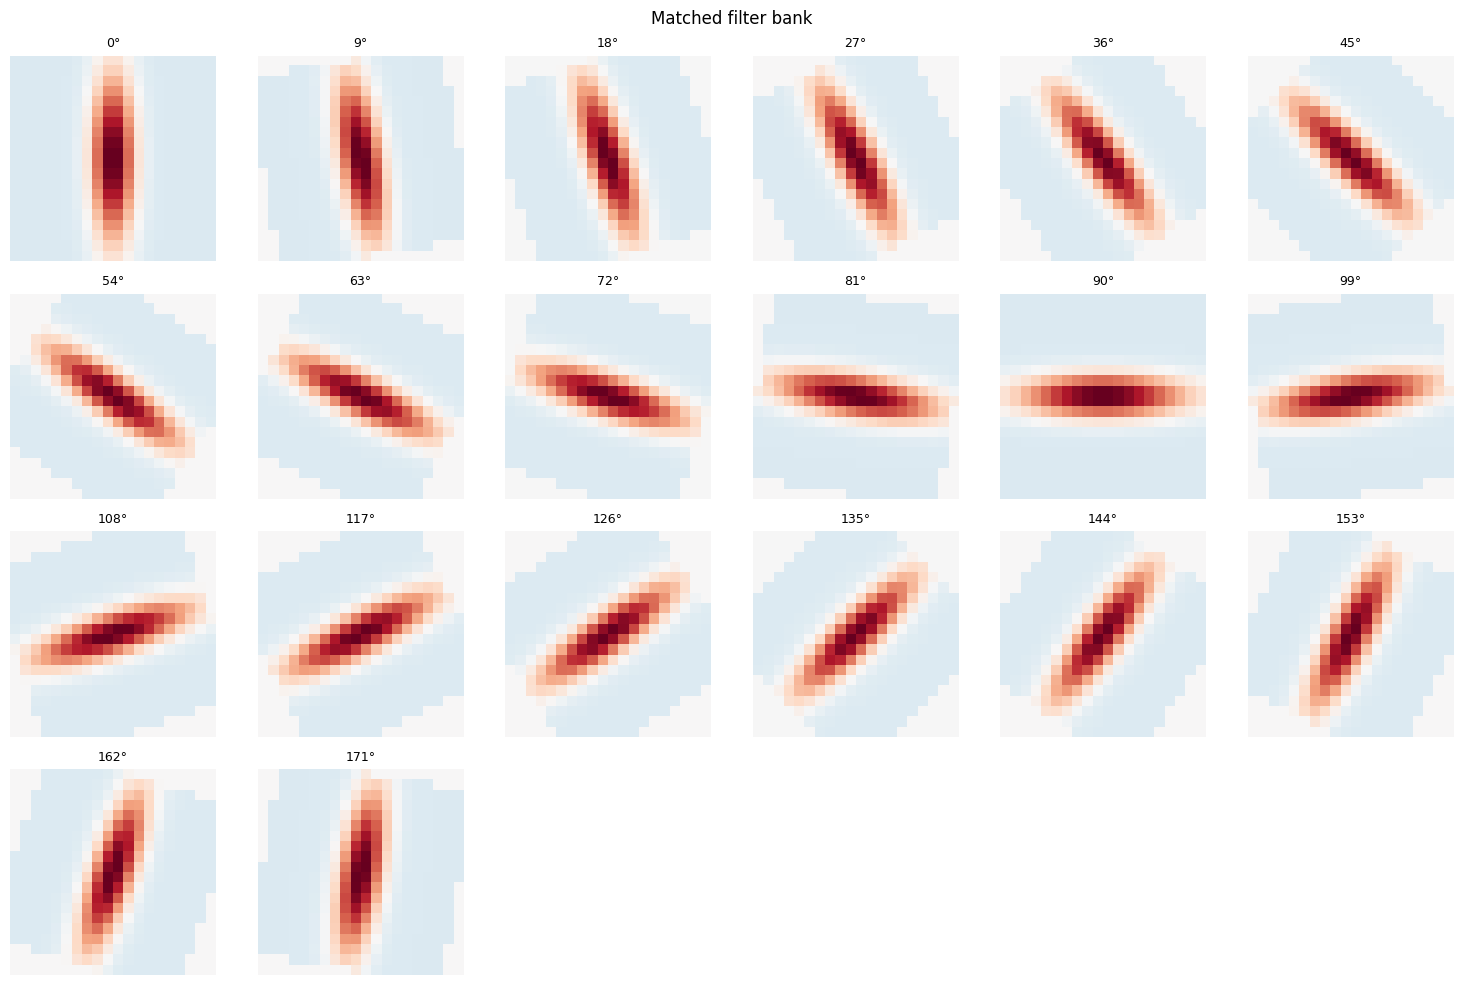

In [15]:
filter_bank = build_filter_bank(N_ORIENTATIONS, SIGMA_X, SIGMA_Y, KERNEL_SIZE)

cols = 6
rows = (N_ORIENTATIONS + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
axes = axes.flatten()

for i, (angle, kernel) in enumerate(filter_bank):
    axes[i].imshow(kernel, cmap="RdBu_r", vmin=-kernel.max(), vmax=kernel.max())
    axes[i].set_title(f"{angle:.0f}°", fontsize=9)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Matched filter bank", fontsize=12)
plt.tight_layout()
plt.show()

## Run predictions on all samples

In [16]:
exts  = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
images = sorted(p for p in SAMPLES_DIR.iterdir() if p.suffix.lower() in exts)

print(f"Orientations : {N_ORIENTATIONS}  (0° – {180 - 180 // N_ORIENTATIONS}°)")
print(f"Kernel       : {KERNEL_SIZE}×{KERNEL_SIZE}  σ_x={SIGMA_X}  σ_y={SIGMA_Y}")
print(f"Threshold    : {THRESHOLD_METHOD}" + (f"  (p={PERCENTILE})" if THRESHOLD_METHOD == "percentile" else ""))
print(f"Output dir   : {OUTPUT_DIR.resolve()}")
print(f"Images       : {len(images)}\n")

# Build filter bank once — reused for every image
filter_bank = build_filter_bank(N_ORIENTATIONS, SIGMA_X, SIGMA_Y, KERNEL_SIZE)

for img_path in images:
    print(f"  {img_path.name} ...", end=" ", flush=True)
    img      = load_grayscale(img_path)
    response = apply_filter_bank(img, filter_bank)
    binary   = threshold_response(response)
    mask     = postprocess(binary)
    out_path = OUTPUT_DIR / (img_path.stem + "_mask.png")
    save_mask(mask, out_path)
    print(f"-> {out_path.name}")

print("\nDone.")

Orientations : 20  (0° – 171°)
Kernel       : 20×20  σ_x=1.5  σ_y=6.0
Threshold    : percentile  (p=97.0)
Output dir   : /Users/ramyar/Git/Realistic_Crack/Unsupervised methods/output/method2_matched_filter
Images       : 12

  front_0263_1A_220kv.png ... -> front_0263_1A_220kv_mask.png
  front_1100_3A_135kv.png ... -> front_1100_3A_135kv_mask.png
  front_1208_3A_220kv.png ... 

KeyboardInterrupt: 

## Visual inspection — image | max-response map | binary mask

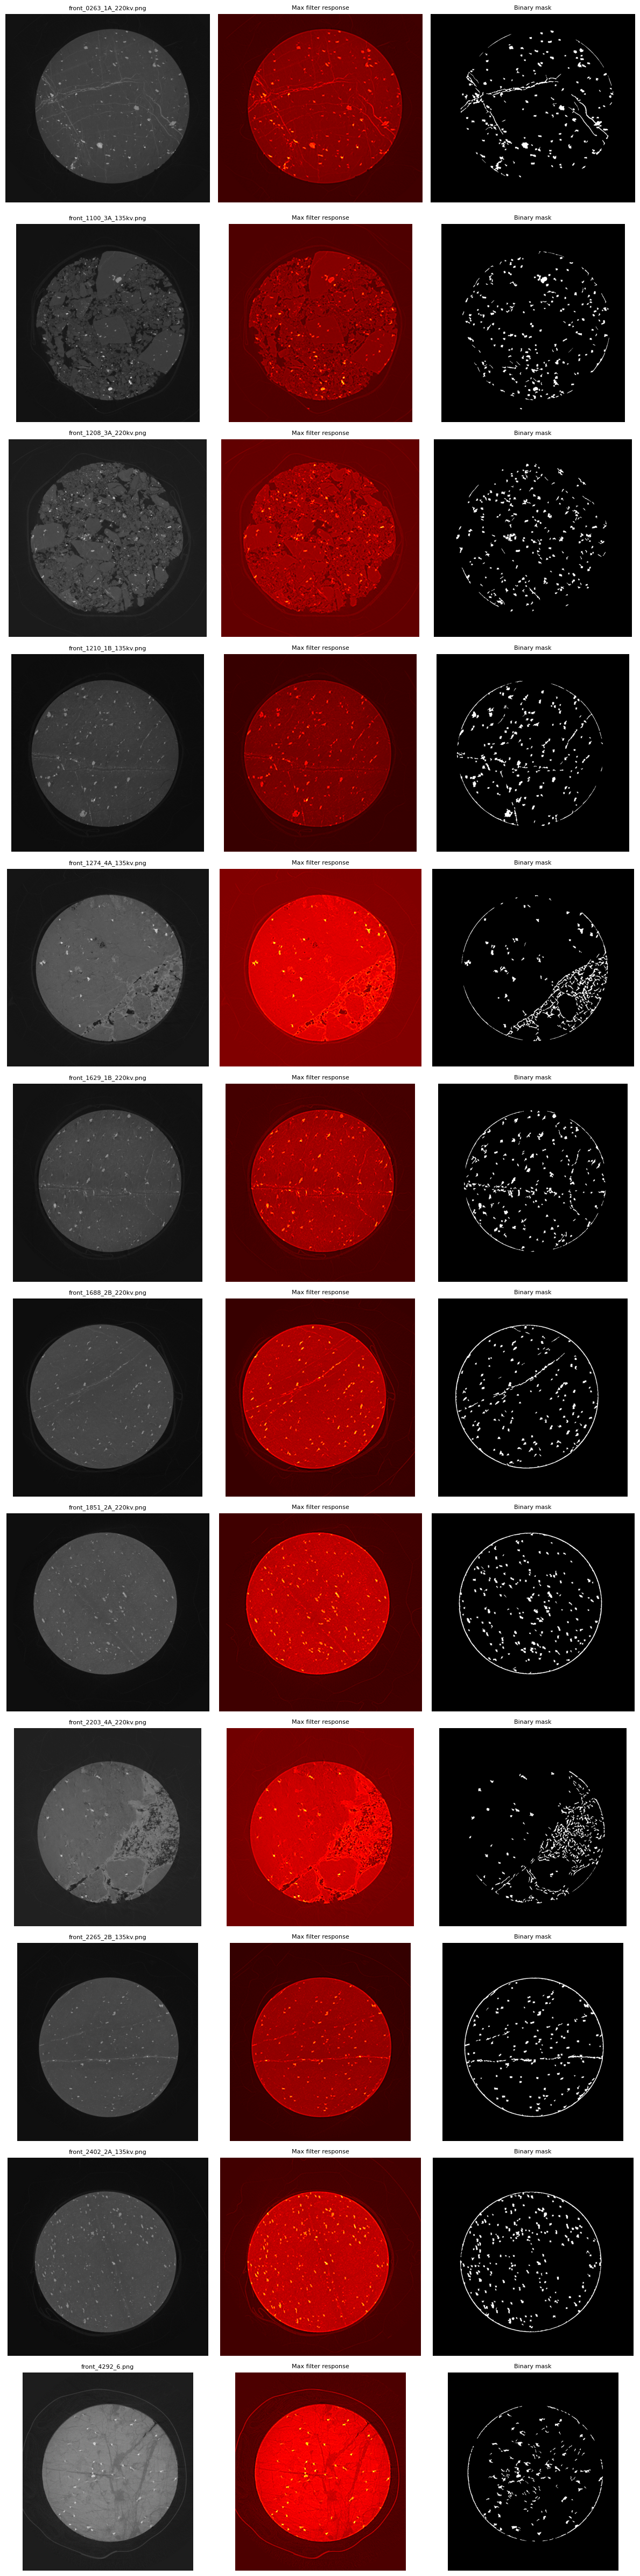

In [6]:
fig, axes = plt.subplots(len(images), 3, figsize=(12, 4 * len(images)))
if len(images) == 1:
    axes = [axes]

for ax_row, img_path in zip(axes, images):
    img      = load_grayscale(img_path)
    response = apply_filter_bank(img, filter_bank)
    binary   = threshold_response(response)
    mask     = postprocess(binary)

    ax_row[0].imshow(img, cmap="gray")
    ax_row[0].set_title(img_path.name, fontsize=8)
    ax_row[0].axis("off")

    ax_row[1].imshow(response, cmap="hot")
    ax_row[1].set_title("Max filter response", fontsize=8)
    ax_row[1].axis("off")

    ax_row[2].imshow(mask, cmap="gray")
    ax_row[2].set_title("Binary mask", fontsize=8)
    ax_row[2].axis("off")

plt.tight_layout()
plt.show()